# 🤖 Passos Mágicos – Modelo Preditivo de Risco
## Pipeline operacional alinhado ao Plano Mestre e ao app atual

### ❓ Pergunta 9
> *"Quais padrões nos indicadores permitem identificar alunos em risco antes de uma queda no desempenho ou aumento da defasagem?"*

### Nota de alinhamento
- o **Plano Mestre** enquadra essa frente dentro do eixo de IA/Deep Learning;
- o **estado operacional atual do repositório e do app publicado** usa um **modelo probabilístico tabular calibrado**;
- este notebook documenta o **pipeline vigente**, coerente com `app/`, `modelo_meta_clean.json` e `notebooks/retrain_model.py`.

### Fluxo do notebook
1. **Carga e limpeza** da base PEDE
2. **Feature engineering alinhado ao plano mestre**
3. **NLP lexical** sobre recomendações e destaques
4. **Pré-processamento** com imputação e normalização
5. **Treino do modelo operacional** de risco
6. **Avaliação** com ROC-AUC, matriz de confusão e análise de coeficientes
7. **Salvamento de artefatos** compatíveis com o app atual


## 0. Instalação e Imports

In [1]:
# Instale se necessário:
# pip install scikit-learn seaborn matplotlib pandas numpy joblib nbformat

import json
import unicodedata
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

CSV_PATH = '../data/BASE DE DADOS PEDE 2024 - DATATHON - PEDE2022.csv'
OUT_MODEL = '../app/modelo_risco_clean.pkl'
OUT_SCALER = '../app/scaler_clean.pkl'
OUT_META = '../app/modelo_meta_clean.json'
OUT_IMPUTER = '../app/modelo_risco_clean_imputer.pkl'
INDE_THRESHOLD = 6.5
THRESHOLD_OPERACIONAL = 0.30

plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})
CORES = ['#1A3A5C', '#E8562A', '#4CAF9A', '#F4A259']
print('✅ Ambiente pronto!')

✅ Ambiente pronto!


## 1. Carregamento e Limpeza

In [2]:
df = None
for encoding in ['utf-8-sig', 'cp1252', 'latin1']:
    try:
        df = pd.read_csv(CSV_PATH, encoding=encoding)
        print(f'Arquivo lido com encoding: {encoding}')
        break
    except UnicodeDecodeError as exc:
        print(f'Falhou com {encoding}: {exc}')

if df is None:
    raise ValueError('Não foi possível carregar o CSV com os encodings testados.')

df.columns = df.columns.str.strip()
print(f'Shape original: {df.shape}')
print('Primeiras colunas:', list(df.columns[:10]))

Arquivo lido com encoding: utf-8-sig
Shape original: (860, 42)
Primeiras colunas: ['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20']


## 2. Funções auxiliares e NLP

In [3]:
def to_num(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '.', regex=False), errors='coerce')


def normalize_text(value):
    text = unicodedata.normalize('NFKD', str(value).strip().lower())
    return ''.join(ch for ch in text if not unicodedata.combining(ch))


def get_matching_col(df_ref, *aliases):
    normalized = {normalize_text(col): col for col in df_ref.columns}
    for alias in aliases:
        match = normalized.get(normalize_text(alias))
        if match:
            return match
    return None


def map_pedra(value):
    return {
        'quartzo': 1,
        'agata': 2,
        'ametista': 3,
        'topazio': 4,
    }.get(normalize_text(value), np.nan)


def dynamic_weights(fase_series):
    fase = pd.to_numeric(fase_series, errors='coerce').fillna(0)
    fase_8 = fase >= 8
    return {
        'ian_num': np.where(fase_8, 0.00, 0.10),
        'ida_num': np.where(fase_8, 0.40, 0.20),
        'ieg_num': np.full(len(fase), 0.20),
        'iaa_num': np.where(fase_8, 0.00, 0.10),
        'ips_num': np.full(len(fase), 0.20),
        'ipp_num': np.full(len(fase), 0.10),
        'ipv_num': np.full(len(fase), 0.10),
    }


def reverse_rank_score(series):
    numeric = to_num(series)
    valid = numeric.dropna()
    if valid.empty or valid.max() == valid.min():
        bounds = {'min': np.nan, 'max': np.nan}
        return pd.Series(np.nan, index=series.index, dtype=float), bounds
    lower = float(valid.min())
    upper = float(valid.max())
    score = 10 * (1 - (numeric - lower) / (upper - lower))
    score = score.clip(0, 10)
    return score.astype(float), {'min': lower, 'max': upper}


PALAVRAS_NEG = {
    'melhorar', 'empenhar', 'dificuldade', 'atraso', 'deficit', 'atencao',
    'problema', 'risco', 'alerta', 'comportamento', 'limitacao', 'preocupa',
    'atenção', 'limitação', 'preocupação'
}
PALAVRAS_POS = {
    'destaque', 'excelente', 'promovido', 'bolsa', 'lider', 'potencial',
    'engajado', 'comprometido', 'aprovado', 'evolucao', 'crescimento',
    'líder', 'evolução'
}


def score_sentimento(texto):
    if pd.isna(texto):
        return 0
    content = str(texto).lower()
    return sum(1 for p in PALAVRAS_POS if p in content) - sum(1 for p in PALAVRAS_NEG if p in content)


print('✅ Funções auxiliares carregadas.')

✅ Funções auxiliares carregadas.


## 3. Feature Engineering – Plano Mestre + App Atual

In [4]:
def build_master_features(df_ref):
    df_ref = df_ref.copy()

    fase_col = get_matching_col(df_ref, 'Fase')
    inde_col = get_matching_col(df_ref, 'INDE 22')
    pedra_22_col = get_matching_col(df_ref, 'Pedra 22')
    pedra_21_col = get_matching_col(df_ref, 'Pedra 21')
    nav_col = get_matching_col(df_ref, 'Nº Av', 'N° Av', 'N Av', 'no_av')

    required = {
        'Fase': fase_col, 'INDE 22': inde_col, 'Pedra 22': pedra_22_col,
        'Pedra 21': pedra_21_col, 'IAN': get_matching_col(df_ref, 'IAN'),
        'IDA': get_matching_col(df_ref, 'IDA'), 'IEG': get_matching_col(df_ref, 'IEG'),
        'IAA': get_matching_col(df_ref, 'IAA'), 'IPS': get_matching_col(df_ref, 'IPS'),
        'IPV': get_matching_col(df_ref, 'IPV'), 'Cf': get_matching_col(df_ref, 'Cf'),
        'Ct': get_matching_col(df_ref, 'Ct'),
    }
    missing = [name for name, col in required.items() if col is None]
    if missing:
        raise ValueError(f'Colunas obrigatórias ausentes: {missing}')

    df_ref['fase'] = to_num(df_ref[fase_col])
    df_ref['ian_num'] = to_num(df_ref[required['IAN']])
    df_ref['ida_num'] = to_num(df_ref[required['IDA']])
    df_ref['ieg_num'] = to_num(df_ref[required['IEG']])
    df_ref['iaa_num'] = to_num(df_ref[required['IAA']])
    df_ref['ips_num'] = to_num(df_ref[required['IPS']])
    df_ref['ipv_num'] = to_num(df_ref[required['IPV']])
    df_ref['inde_num'] = to_num(df_ref[inde_col])

    df_ref['pedra_22_num'] = df_ref[pedra_22_col].apply(map_pedra)
    df_ref['pedra_21_num'] = df_ref[pedra_21_col].apply(map_pedra)
    df_ref['evolucao_pedra'] = df_ref['pedra_22_num'] - df_ref['pedra_21_num']
    df_ref['no_av'] = to_num(df_ref[nav_col]) if nav_col else np.nan

    cf_score, cf_bounds = reverse_rank_score(df_ref[required['Cf']])
    ct_score, ct_bounds = reverse_rank_score(df_ref[required['Ct']])
    df_ref['ipp_num'] = pd.concat([cf_score, ct_score], axis=1).mean(axis=1)

    cols_rec = [
        col for col in df_ref.columns
        if any(tag in normalize_text(col) for tag in ['rec av', 'rec ps', 'destaque'])
    ]
    df_ref['sent_score'] = sum(df_ref[col].apply(score_sentimento) for col in cols_rec) if cols_rec else 0.0
    df_ref['sent_len'] = (
        sum(df_ref[col].apply(lambda x: len(str(x)) if not pd.isna(x) else 0) for col in cols_rec)
        if cols_rec else 0.0
    )

    weights = dynamic_weights(df_ref['fase'])
    w_acad = weights['ian_num'] + weights['ida_num']
    w_psico = weights['ieg_num'] + weights['iaa_num'] + weights['ips_num']
    w_peda = weights['ipp_num'] + weights['ipv_num']

    df_ref['dim_academica'] = (
        df_ref['ian_num'] * weights['ian_num'] + df_ref['ida_num'] * weights['ida_num']
    ) / w_acad
    df_ref['dim_psicossocial'] = (
        df_ref['ieg_num'] * weights['ieg_num']
        + df_ref['iaa_num'] * weights['iaa_num']
        + df_ref['ips_num'] * weights['ips_num']
    ) / w_psico
    df_ref['dim_psicopedagogica'] = (
        df_ref['ipp_num'] * weights['ipp_num'] + df_ref['ipv_num'] * weights['ipv_num']
    ) / w_peda
    df_ref['inde_calc'] = (
        df_ref['ian_num'] * weights['ian_num']
        + df_ref['ida_num'] * weights['ida_num']
        + df_ref['ieg_num'] * weights['ieg_num']
        + df_ref['iaa_num'] * weights['iaa_num']
        + df_ref['ips_num'] * weights['ips_num']
        + df_ref['ipp_num'] * weights['ipp_num']
        + df_ref['ipv_num'] * weights['ipv_num']
    )

    return df_ref, {'cf': cf_bounds, 'ct': ct_bounds, 'source': 'reverse_rank_cf_ct'}, cols_rec


df, ipp_bounds, cols_rec = build_master_features(df)
df['em_risco'] = (df['inde_num'] < INDE_THRESHOLD).astype(int)

FEATURES = [
    'dim_academica', 'dim_psicossocial', 'dim_psicopedagogica',
    'fase', 'pedra_22_num', 'pedra_21_num', 'evolucao_pedra',
    'no_av', 'sent_score', 'sent_len'
]
TARGET = 'em_risco'

df_model = df[FEATURES + [TARGET]].copy()
for feature in FEATURES:
    df_model[feature] = pd.to_numeric(df_model[feature], errors='coerce')

imputer = SimpleImputer(strategy='median')
df_model[FEATURES] = imputer.fit_transform(df_model[FEATURES])

print('Target alinhado ao app: em_risco = (INDE 22 < 6.5)')
print(df[TARGET].value_counts(normalize=True).rename({0: 'Sem risco', 1: 'Em risco'}).round(3))
print(f'Campos textuais usados no NLP: {cols_rec if cols_rec else "nenhum"}')
print(f'Dataset de modelagem: {df_model.shape[0]} amostras, {len(FEATURES)} features')
df_model.describe().round(2)

Target alinhado ao app: em_risco = (INDE 22 < 6.5)
em_risco
Sem risco    0.748
Em risco     0.252
Name: proportion, dtype: float64
Campos textuais usados no NLP: ['Rec Av1', 'Rec Av2', 'Rec Av3', 'Rec Av4', 'Rec Psicologia', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']
Dataset de modelagem: 860 amostras, 10 features


,dim_academica,dim_psicossocial,dim_psicopedagogica,fase,pedra_22_num,pedra_21_num,evolucao_pedra,no_av,sent_score,sent_len,em_risco
count,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00,860.00
mean,6.20,7.57,6.83,2.10,2.55,2.83,-0.10,3.05,0.85,234.83,0.25
std,1.68,1.02,1.52,1.79,0.93,0.69,0.62,0.78,3.46,14.31,0.43
min,0.83,2.00,2.61,0.00,1.00,1.00,-2.00,2.00,-4.00,206.00,0.00
25%,5.07,7.06,5.70,1.00,2.00,3.00,0.00,2.00,-2.00,224.00,0.00
50%,6.40,7.76,6.89,2.00,3.00,3.00,0.00,3.00,0.00,230.00,0.00
75%,7.40,8.34,7.99,3.00,3.00,3.00,0.00,4.00,3.00,249.25,1.00
max,9.93,9.64,10.00,7.00,4.00,4.00,3.00,4.00,11.00,269.00,1.00


## 4. Separação Treino/Teste e Normalização

In [5]:
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Treino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Taxa de risco no treino: {y_train.mean()*100:.1f}%')
print(f'Taxa de risco no teste:  {y_test.mean()*100:.1f}%')

Treino: 688 | Teste: 172
Taxa de risco no treino: 25.3%
Taxa de risco no teste:  25.0%


## 5. Modelo Operacional de Risco

In [6]:
model = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='roc_auc')
model.fit(X_train_sc, y_train)

y_prob = model.predict_proba(X_test_sc)[:, 1]
threshold = THRESHOLD_OPERACIONAL
y_pred = (y_prob >= threshold).astype(int)
test_auc = roc_auc_score(y_test, y_prob)

print(f'CV AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'AUC teste: {test_auc:.4f}')
print(f'Threshold operacional adotado: {threshold:.2f}')
print(classification_report(y_test, y_pred, target_names=['Sem Risco', 'Em Risco']))

coef_df = pd.DataFrame({'Feature': FEATURES, 'Coeficiente': model.coef_[0]})    .sort_values('Coeficiente')
coef_df

CV AUC (5-fold): 0.9953 ± 0.0036


AUC teste: 0.9996
Threshold operacional adotado: 0.30
              precision    recall  f1-score   support

   Sem Risco       1.00      0.98      0.99       129
    Em Risco       0.96      1.00      0.98        43

    accuracy                           0.99       172
   macro avg       0.98      0.99      0.98       172
weighted avg       0.99      0.99      0.99       172



,Feature,Coeficiente
0,dim_academica,-2.947531
1,dim_psicossocial,-2.719301
2,dim_psicopedagogica,-2.184864
8,sent_score,-1.371070
4,pedra_22_num,-0.754742
9,sent_len,-0.206044
5,pedra_21_num,-0.073895
7,no_av,-0.043362
6,evolucao_pedra,0.104788
3,fase,1.297830


## 6. Avaliação do Modelo

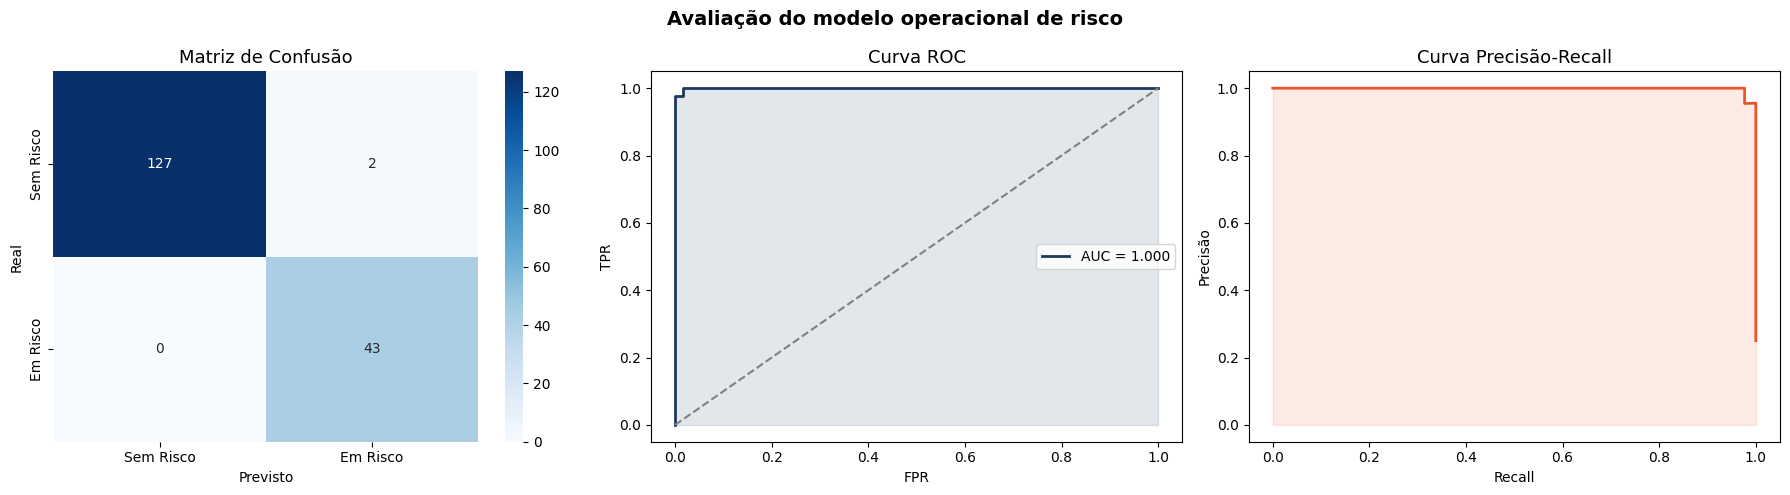

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Sem Risco', 'Em Risco'],
    yticklabels=['Sem Risco', 'Em Risco']
)
axes[0].set_title('Matriz de Confusão')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=CORES[0], lw=2, label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].fill_between(fpr, tpr, alpha=0.12, color=CORES[0])
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, color=CORES[1], lw=2)
axes[2].fill_between(rec, prec, alpha=0.12, color=CORES[1])
axes[2].set_title('Curva Precisão-Recall')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precisão')

plt.suptitle('Avaliação do modelo operacional de risco', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/fig_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

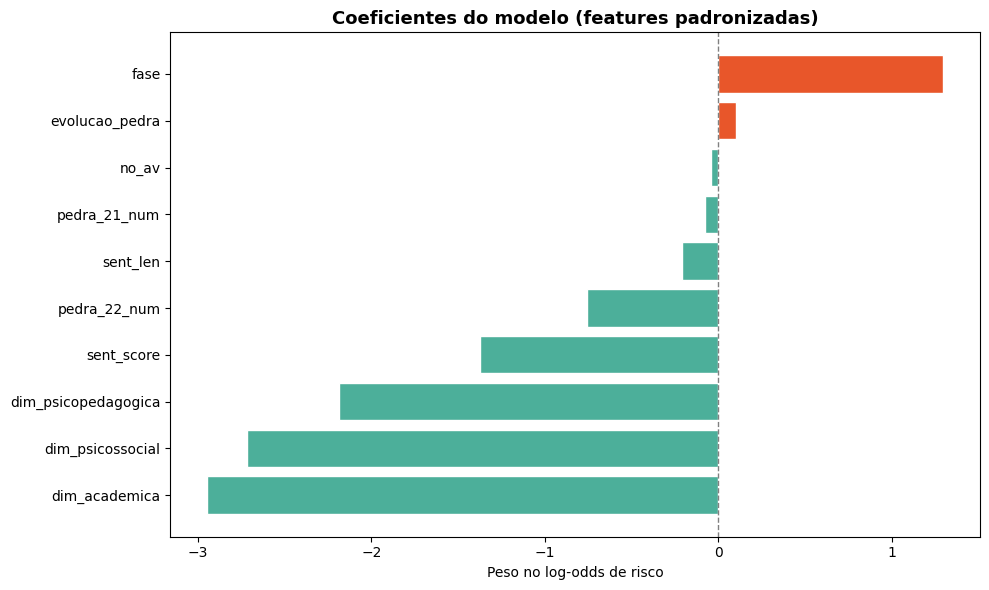

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_df = coef_df.copy()
colors = ['#4CAF9A' if value < 0 else '#E8562A' for value in plot_df['Coeficiente']]
ax.barh(plot_df['Feature'], plot_df['Coeficiente'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes do modelo (features padronizadas)', fontsize=13, fontweight='bold')
ax.set_xlabel('Peso no log-odds de risco')
plt.tight_layout()
plt.savefig('../data/fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salvar Artefatos Compatíveis com o App

In [9]:
joblib.dump(model, OUT_MODEL)
joblib.dump(scaler, OUT_SCALER)
joblib.dump(imputer, OUT_IMPUTER)

meta = {
    'features': FEATURES,
    'threshold': THRESHOLD_OPERACIONAL,
    'inde_threshold': INDE_THRESHOLD,
    'target_description': f'INDE 22 < {INDE_THRESHOLD}',
    'probability_calibration': {
        'method': 'logit_temperature',
        'clip_epsilon': 1e-6,
        'temperature': 3.5,
        'bias': 3.8,
        'description': 'Pós-calibração para reduzir saturação e melhorar discriminação entre perfis médio e crítico.',
    },
    'model_family': 'logistic_regression',
    'alignment': 'plano_mestre_dimensoes_consolidadas',
    'input_mode': 'master_plan_indicators',
    'ipp_proxy_description': 'Proxy conservador: média de Cf/Ct invertidos para escala 0-10.',
    'ipp_proxy_bounds': ipp_bounds,
    'inde_weights': {
        'fase_0_7': {'ian_num': 0.10, 'ida_num': 0.20, 'ieg_num': 0.20, 'iaa_num': 0.10, 'ips_num': 0.20, 'ipp_num': 0.10, 'ipv_num': 0.10},
        'fase_8': {'ian_num': 0.00, 'ida_num': 0.40, 'ieg_num': 0.20, 'iaa_num': 0.00, 'ips_num': 0.20, 'ipp_num': 0.10, 'ipv_num': 0.10},
    },
    'dimension_weights': {
        'fase_0_7': {'dim_academica': 0.30, 'dim_psicossocial': 0.50, 'dim_psicopedagogica': 0.20},
        'fase_8': {'dim_academica': 0.40, 'dim_psicossocial': 0.40, 'dim_psicopedagogica': 0.20},
    },
    'cv_auc_mean': round(float(cv_scores.mean()), 4),
    'cv_auc_std': round(float(cv_scores.std()), 4),
    'test_auc': round(float(test_auc), 4),
    'num_features': len(FEATURES),
    'y_distribution': {'1': int(y.sum()), '0': int((y == 0).sum())},
    'imputer_medians': {feature: float(imputer.statistics_[i]) for i, feature in enumerate(FEATURES)},
}

with open(OUT_META, 'w', encoding='utf-8') as fp:
    json.dump(meta, fp, indent=2, ensure_ascii=False)

print(f'✅ Modelo salvo:  {OUT_MODEL}')
print(f'✅ Scaler salvo:  {OUT_SCALER}')
print(f'✅ Imputer salvo: {OUT_IMPUTER}')
print(f'✅ Meta salvo:    {OUT_META}')

✅ Modelo salvo:  ../app/modelo_risco_clean.pkl
✅ Scaler salvo:  ../app/scaler_clean.pkl
✅ Imputer salvo: ../app/modelo_risco_clean_imputer.pkl
✅ Meta salvo:    ../app/modelo_meta_clean.json


---
## ✅ Resumo do Modelo Preditivo

| Aspecto | Detalhe |
|---------|---------|
| **Target** | `em_risco = (INDE 22 < 6.5)` |
| **Features** | 3 dimensões consolidadas + contexto de fase, pedra, nº de avaliações e NLP |
| **Alinhamento** | `plano_mestre_dimensoes_consolidadas` |
| **Modelo operacional** | Regressão logística padronizada |
| **Threshold** | `0.30`, coerente com o metadado do app atual |
| **Output** | Probabilidade de risco (0–100%) |
| **Artefatos** | `modelo_risco_clean.pkl`, `scaler_clean.pkl`, `modelo_meta_clean.json` |
